# AI Image Embedding Clustering and Visual Search

**Objective:** Cluster image embeddings and retrieve visually related assets using a compact offline stand-in for CLIP-style vectors.

The notebook uses deterministic 48-dimensional vectors as an offline stand-in for image embeddings. A production version can replace them with validated CLIP or vision-model embeddings without changing the clustering and retrieval stages.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Build a documented embedding collection


In [2]:
THEMES = ["data_visualization", "code_screenshot", "product_photo", "portrait", "landscape"]
DIMENSIONS = 48
centers = rng.normal(0, 1, size=(len(THEMES), DIMENSIONS))
centers = centers / np.linalg.norm(centers, axis=1, keepdims=True) * 5
rows, vectors = [], []
for theme_id, theme in enumerate(THEMES):
    for item_id in range(70):
        vector = centers[theme_id] + rng.normal(0, 0.42, DIMENSIONS)
        vectors.append(vector)
        rows.append({"asset_id": f"img-{theme_id}-{item_id:03d}", "generator_theme": theme})
embeddings = np.asarray(vectors)
assets = pd.DataFrame(rows)
print(f"Embedding matrix: {embeddings.shape}")
display(assets.head())


Embedding matrix: (350, 48)


,asset_id,generator_theme
0,img-0-000,data_visualization
1,img-0-001,data_visualization
2,img-0-002,data_visualization
3,img-0-003,data_visualization
4,img-0-004,data_visualization


## 3. Cluster selection and interpretation


In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import Normalizer

X = Normalizer().fit_transform(embeddings)
selection = []
for k in range(2, 8):
    labels = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE).fit_predict(X)
    selection.append({"k": k, "cosine_silhouette": silhouette_score(X, labels, metric="cosine")})
selection = pd.DataFrame(selection)
display(selection.round(4))
best_k = int(selection.loc[selection["cosine_silhouette"].idxmax(), "k"])
model = KMeans(n_clusters=best_k, n_init=40, random_state=RANDOM_STATE).fit(X)
assets["cluster"] = model.labels_
display(pd.crosstab(assets["generator_theme"], assets["cluster"], margins=True))
print(f"Selected k={best_k}; retrospective ARI={adjusted_rand_score(assets['generator_theme'], assets['cluster']):.4f}")


Selected k=5; retrospective ARI=1.0000


,k,cosine_silhouette
0,2,0.3600
1,3,0.4644
2,4,0.5862
3,5,0.7026
4,6,0.5715
5,7,0.4467


cluster,0,1,2,3,4,All
generator_theme,,,,,,
code_screenshot,70,0,0,0,0,70
data_visualization,0,70,0,0,0,70
landscape,0,0,0,0,70,70
portrait,0,0,70,0,0,70
product_photo,0,0,0,70,0,70
All,70,70,70,70,70,350


## 4. Visual search with cosine neighbours


In [4]:
from sklearn.neighbors import NearestNeighbors

neighbours = NearestNeighbors(n_neighbors=7, metric="cosine").fit(X)
query_index = 12
distances, indices = neighbours.kneighbors(X[query_index:query_index + 1])
results = assets.iloc[indices[0]].copy()
results["cosine_similarity"] = 1 - distances[0]
print(f"Query asset: {assets.loc[query_index, 'asset_id']} ({assets.loc[query_index, 'generator_theme']})")
display(results.round(4))


Query asset: img-0-012 (data_visualization)


,asset_id,generator_theme,cluster,cosine_similarity
12,img-0-012,data_visualization,1,1.0000
36,img-0-036,data_visualization,1,0.8026
64,img-0-064,data_visualization,1,0.7990
62,img-0-062,data_visualization,1,0.7980
16,img-0-016,data_visualization,1,0.7892
61,img-0-061,data_visualization,1,0.7887
33,img-0-033,data_visualization,1,0.7873


## 5. Two-dimensional embedding map


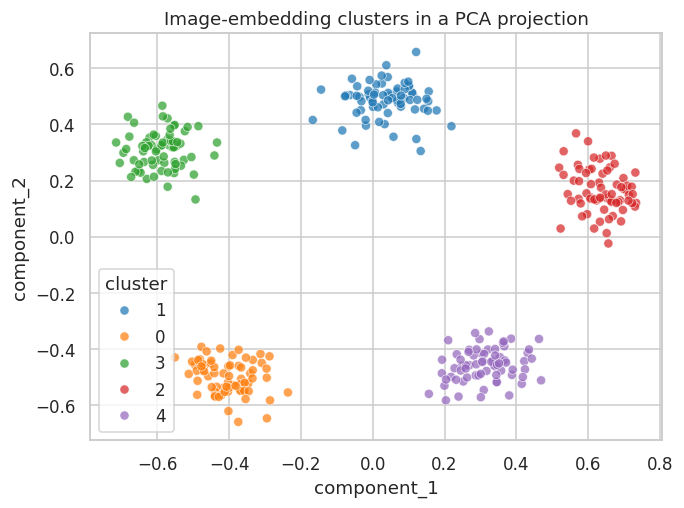

In [5]:
from sklearn.decomposition import PCA

projection = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
plot_data = pd.DataFrame({"component_1": projection[:, 0], "component_2": projection[:, 1], "cluster": assets["cluster"].astype(str)})
sns.scatterplot(data=plot_data, x="component_1", y="component_2", hue="cluster", palette="tab10", alpha=0.72)
plt.title("Image-embedding clusters in a PCA projection")
plt.tight_layout()
plt.show()


## 6. Findings and limitations

- The demo validates clustering, retrieval, and inspection logic without downloading a vision model.
- Production quality depends on the embedding model, image domain, duplicate policy, and human relevance checks.
- Two-dimensional maps are diagnostic views, not proof that clusters are intrinsically separated.
